In [ ]:
# import pandas as pd
# name='352'
# long_name='3524m031'
# band='w1'
# table = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_mached.csv')

In [2]:
import numpy as np
import pandas as pd

def calculate_magnitude(flux):
    if flux <= 0:
        return np.nan
    return 22.5 - 2.5 * np.log10(flux)

def calculate_error(flux,dflux):
    mag_upper = calculate_magnitude(flux - dflux)
    mag_lower = calculate_magnitude(flux + dflux)
    dmag = (mag_upper - mag_lower) / 2
    return dmag

cal_mag_ufunc  = np.frompyfunc(calculate_magnitude,1,1)
cal_error_ufunc  = np.frompyfunc(calculate_error,2,1)
def make_single_light_curve(table, index):
    line = table.iloc[index]
    line_len = len(line)
    ra = line[0]
    dec = line[1]
    flux_unfiltered = line[3:line_len:3]
    flux = np.array(flux_unfiltered[flux_unfiltered.notnull()])
    dflux_unfiltered = line[4:line_len:3]
    dflux = np.array(dflux_unfiltered[dflux_unfiltered.notnull()])
    mjdmean_unfiltered = line[5:line_len:3]
    mjdmean = np.array(mjdmean_unfiltered[mjdmean_unfiltered.notnull()])
    assert len(flux)==len(dflux) and len(dflux)==len(mjdmean), 'light curve uncomplete!'
    mag = cal_mag_ufunc(flux)
    error = cal_error_ufunc(flux,dflux)
    assert len(mag)==len(error) , 'light curve errors uncomplete!'
    return ra, dec, mag, error, mjdmean,flux, dflux

In [3]:
def reduced_chi_Square_self(flux,error):
    sigma2 = np.power(error,2)
    mean_flux = np.sum(np.divide(flux,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(flux)
    return np.sum(np.divide(np.power(flux-mean_flux,2),sigma2))/N -1 


def weighted_sigma(mag,error):
    sigma2 = np.power(error,2)
    weights = np.divide(1,sigma2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sqrt(np.sum(weights)*np.sum(np.multiply(weights,np.power(mag-mean_mag,2)))/(np.sum(weights)**2-np.sum(np.power(weights,2))))


from scipy import stats
def Median_absolute_deviation_self(mag):
    return stats.median_abs_deviation(mag)

def Interquartile_range(mag):
    return stats.iqr(mag)

def Robust_median_statistic(mag,error):
    N = len(mag)
    median_mag = np.median(mag)
    return np.sum(np.divide(np.abs(mag-median_mag),error))/(N-1)

def Normalized_excess_variance(mag,error):
    """
    Calculate the normalized excess variance of a light curve.
    """
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sum(np.power(mag-mean_mag,2)-sigma2)/(len(mag)*mean_mag**2) 

def Peak_to_peak_variability(mag,error):
    return (np.max(mag-error)-np.min(mag+error))/(np.max(mag-error)+np.min(mag+error))

def Lag_1_autocorrelation(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    mag_shifted = mag - mean_mag    
    lag_1_autocorr = np.sum(np.multiply(mag_shifted[1:],mag_shifted[:-1]))/np.sum(mag_shifted**2)  
    return lag_1_autocorr    

def Stetson_J_self(mag,error):
    """
    Stetson J index
    """    
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(mag)
    delta = np.divide(np.sqrt(N/(N-1))*(mag-mean_mag),error)
    product = np.multiply(delta[1:],delta[:-1])
    return np.sum(np.multiply(np.sign(product),np.sqrt(np.abs(product).astype(np.float32))))

def Stetson_K(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(mag)
    delta = np.divide(np.sqrt(N/(N-1))*(mag-mean_mag),error)
    denominator = np.sqrt(np.sum(np.power(delta,2)*(1/N)))
    return (1/N)*np.sum(np.abs(delta))/denominator

def yita(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sum(np.power(mag[1:]-mag[:-1],2))/np.sum(np.power(mag-mean_mag,2))

In [13]:
def w1_w2_corelation(mags1,mags2,mjdmean1,mjdmean2):
    aligned_mags1 = []
    aligned_mags2 = []
    w1_pointer = 0
    same_time_limit = 7 if len(mjdmean1) < 100 else 2

    i = 0
    while i < len(mags2):
        if abs(mjdmean2[i] - mjdmean1[w1_pointer]) < same_time_limit:
            aligned_mags1.append(mags1[w1_pointer])
            aligned_mags2.append(mags2[i])
            w1_pointer += 1
            i += 1
        elif mjdmean2[i] > mjdmean1[w1_pointer]:
            w1_pointer += 1
        else:
            i+=1            
        if w1_pointer >= len(mags1):
            break  
    return len(aligned_mags1), np.corrcoef(aligned_mags1,aligned_mags2)[0,1]

In [ ]:
import numpy as np
mags1 = np.array([1, 2, 3, 5, 5])
mags2 = np.array([1, 2, 3, 4, 5])

# mags2 = np.array([5, 4, 3, 2, 1])

mjdmean1 = np.array([56661,56671,56681,56701,56711])
mjdmean2 = np.array([56661,56671,56681,56691,56701])
w1_w2_corelation(mags1, mags2, mjdmean1, mjdmean2)

In [ ]:
import glob
from multiprocessing import Pool
import time
import os

def one_footprint_download(name,long_name):
    start = time.time()
    os.system("java -jar jystilts.jar one_footprint_match.py "+name+" "+long_name)
    end = time.time()
    print('Task %s runs %0.2f seconds.' % (long_name, (end - start)))

In [ ]:
import glob
from multiprocessing import Pool
import time
import os
first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
thread_pool = Pool()
error_count = 0
for name in first_layer_names:
    second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',
                                root_dir='./mached_catalog/'+name)
    for long_name in second_layer_names:
        if True != os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_mached_2band.csv'):
            thread_pool.apply_async(one_footprint_download,args=(name,long_name))
            # error_count +=1
# print('error count is:',error_count)

print('Waiting for all subprocesses done...')
thread_pool.close()
thread_pool.join()
print('all subprocesses done')

In [4]:
name = '000'
long_name = '0000m016'
table_w1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ 'w1' +'_mached.csv',
                        low_memory=False)
print(table_w1.iloc[0])

ra                0.424221
dec              -2.259413
cc_flags              0000
flux_2           470.68918
dflux_2           27.83273
MJDMEAN_2     55367.857741
flux_3           392.69174
dflux_3          27.582817
MJDMEAN_3     55547.657345
flux_4           398.67383
dflux_4           25.83141
MJDMEAN_4     56644.832601
flux_5           432.65747
dflux_5           23.67042
MJDMEAN_5     56832.811652
flux_6           435.26657
dflux_6          23.569324
MJDMEAN_6     57009.684536
flux_7           409.41956
dflux_7          22.413437
MJDMEAN_7     57194.623313
flux_8           400.35205
dflux_8            25.0747
MJDMEAN_8     57368.804978
flux_9           338.10626
dflux_9          26.477716
MJDMEAN_9     57558.775947
flux_10           414.1774
dflux_10         23.887098
MJDMEAN_10    57729.394016
flux_11           448.9605
dflux_11         27.775116
MJDMEAN_11    57925.880772
flux_12          417.52036
dflux_12         22.043385
MJDMEAN_12    58091.478676
flux_13          408.62524
d

In [14]:
import time
import pickle
def one_footprint_cal_corelation(name,long_name):
    print('Task %s starts' % long_name)
    start = time.time()
    table_w1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ 'w1' +'_mached.csv',
                        low_memory=False)
    table_w2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ 'w2' +'_mached.csv',
                        low_memory=False)
    table_crossmathc = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_mached_2band.csv',
                        low_memory=False)
    result_list = []
    for i in range(0,len(table_crossmathc)):
        id_w1 = table_crossmathc.iloc[i]['id_w1']
        id_w2 = table_crossmathc.iloc[i]['id_w2']
        ra1, dec1, mags1, errors1, mjdmean1, flux1, dflux1 = make_single_light_curve(table_w1,id_w1-1)
        ra2, dec2, mags2, errors2, mjdmean2, flux2, dflux2 = make_single_light_curve(table_w2,id_w2-1)
        if len(mags1)>=10 and (len(mags1)-len(mags2) <= 0.5*len(mags1)):
            try:
                len_aligned, corelation = w1_w2_corelation(mags1,mags2,mjdmean1,mjdmean2)
            except:
                continue
            if len_aligned>=5:
                result_line = np.array([long_name,ra1,dec1,ra2,dec2,id_w1,id_w2,corelation])
                result_list.append(result_line)
    print("cal done fo task %s" % long_name)
    result_table = pd.DataFrame(np.array(result_list),columns=['long_name','ra1','dec1','ra2','dec2','id_w1','id_w2','corelation'])
    result_table.to_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_corelation.csv')
    end = time.time()
    print('Task %s runs %0.dx2f seconds.' % (long_name, (end - start)))

In [4]:
import time
import pickle
def one_footprint_cal(name,long_name,band):
    print('Task %s starts' % long_name)
    start = time.time()
    table = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_mached.csv',
                        low_memory=False)
    result_list = []
    for i in range(0,len(table)):
        ra, dec, mags, errors, mjdmean, flux, dflux = make_single_light_curve(table,i)
        if len(mags)>=10:
            try:
                chi_squre = 0
                mean_mag = np.mean(mags)
                mean_error = np.nanmean(errors)
                for mag,error in zip(mags,errors):
                    chi_squre += ((mag-mean_mag)/error)**2
            except:
                print('Error in calculating chi_squre for %s' % long_name)
                continue 
            
 
            try:
                reduced_chi_Square = reduced_chi_Square_self(flux,dflux)
            except:
                print('Error in calculating reduced_chi_Square for %s' % long_name)
                continue 
            
            try:
                w_sigma = weighted_sigma(mags,errors)
            except:
                print('Error in calculating w_sigma for %s' % long_name)
                continue 
            
            try:
                MAD = Median_absolute_deviation_self(mags)

            except:
                print('Error in calculating MAD for %s' % long_name)
                continue 
            
            try:
                IQR = Interquartile_range(mags)
            except:
                print('Error in calculating IQR for %s' % long_name)
                continue 
            
            try:
                RmStat = Robust_median_statistic(mags,errors)

            except: 
                print('Error in calculating RmStat for %s' % long_name)
                continue 
            
            try:
                Nev = Normalized_excess_variance(mags,errors)

            except: 
                print('Error in calculating Nev for %s' % long_name)
                continue 
            
            try:
                p2pv = Peak_to_peak_variability(mags,errors)
            except: 
                print('Error in calculating p2pv for %s' % long_name)
                continue 
            
            try:
                L1_acr = Lag_1_autocorrelation(mags,errors)
            except: 
                print('Error in calculating L1_acr for %s' % long_name) 
                continue 

            try:
                J = Stetson_J_self(mags,errors)
            except: 
                print('Error in calculating Stetson_J for %s' % long_name)
                continue 
            
            try:    
                K = Stetson_K(mags,errors)   
            except: 
                print('Error in calculating Stetson_K for %s' % long_name)  
                continue
            
            try:
                yta = yita(mags,errors)
            except:
                print('Error in calculating yita for %s' % long_name)
                continue  

            result_line = np.array([long_name, i,ra,dec,mean_mag,chi_squre,reduced_chi_Square,w_sigma,MAD,IQR,RmStat,Nev,p2pv,L1_acr,J,K,yta])
            result_list.append(result_line)
            

        # result_list.append([ra, dec, mags, errors, mjdmean])
    # fw = open('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_light_curves.dat','wb')
    # pickle.dump(result_list,fw)
    
    print("cal done fo task %s" % long_name)
    result_table = pd.DataFrame(np.array(result_list),columns=['long_name','id_in_matched','ra','dec','Mean','chi_squre','rcs','w_sigma','MAD','IQR','RmStat','Nev','p2pv','L1_acr','Stetson_J','Stetson_K','yita'])
    # print(result_table)
    result_table.to_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_new_features.csv')
    end = time.time()
    print('Task %s runs %0.dx2f seconds.' % (long_name, (end - start)))

In [6]:
# one_footprint_cal('000','0000m182','w1')
one_footprint_cal('296','2969p333','w1')
# one_footprint_cal_corelation('000','0000m016')

Task 2969p333 starts
Error in calculating MAD for 2969p333
cal done fo task 2969p333
Task 2969p333 runs 74x2f seconds.


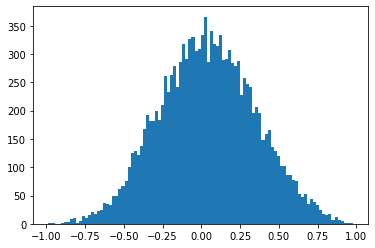

In [16]:
temp_table = pd.read_csv('./mached_catalog/000/0000m016/0000m016_corelation.csv')
import matplotlib.pyplot as plt
plt.hist(np.array(temp_table['corelation']),bins=100)
plt.show()

In [1]:
import glob
import os

first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
for name in first_layer_names:
        os.mkdir('/data/project_unTimely_light_curve/mached_catalog/'+name)
        second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',
                                    root_dir='./mached_catalog/'+name)
        for long_name in second_layer_names:
                os.mkdir('/data/project_unTimely_light_curve/mached_catalog/'+name+'/'+long_name)

In [1]:
from multiprocessing import Pool
import time
import glob
import os


thread_pool = Pool()
first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
for name in first_layer_names:
        
        second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',
                                    root_dir='./mached_catalog/'+name)
        for long_name in second_layer_names:


            if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_mached_2band.csv'):
                if True != os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_corelation.csv'):                                    

                    thread_pool.apply_async(one_footprint_cal_corelation,args=(name,long_name))

print('Waiting for all subprocesses done...')
thread_pool.close()
thread_pool.join()
print('all subprocesses done')

Waiting for all subprocesses done...
all subprocesses done


In [ ]:
from multiprocessing import Pool
import time
import glob
import os

temp_count = 0

thread_pool = Pool()
first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
for name in first_layer_names:
        
        if temp_count > 15:
             break

        second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',
                                    root_dir='./mached_catalog/'+name)
        for long_name in second_layer_names:

            if temp_count > 15:
                 break  

            for band in ('w1', 'w2'):
                if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_mached.csv'):
                    if True != os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_new_features.csv'):
                        
                        temp_count += 1
                        
                        # thread_pool.apply_async(one_footprint_cal,args=(name,long_name,band))


print('Waiting for all subprocesses done...')
thread_pool.close()
thread_pool.join()
print('all subprocesses done')

In [ ]:
# import matplotlib.pyplot as plt
# plt.hist(np.array(result_table['kai_squre']),bins=100,range=(0,100))